# Configuration

In [2]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from scipy.stats import truncnorm, norm
from scipy.optimize import fsolve

In [6]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts

# Simulation

In [20]:
params_dict = {
    'Atlanta Job Corps': (2093, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (785, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

params_dict = {
    'Atlanta Job Corps': (6546, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (1343, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

mu_arr = np.array([params_dict[site][0] for site in params_dict])
se_arr = np.array([params_dict[site][1] for site in params_dict])
cov_arr = np.diag(se_arr ** 2)  # the paper uses standard errors to contruct the covariance matrix

best_site_mu, best_site_se = params_dict['CET/San Jose']

best_scaling = 0.55

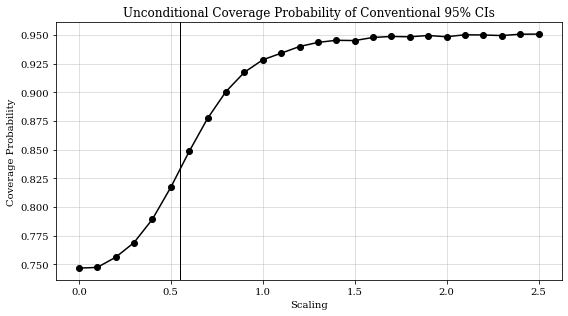

In [7]:
# coverage of conventional 95% CI
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
coverage_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]
    best_se_arr = se_arr[temp_best_site_arr]

    is_cover_arr = (best_mu_arr - 1.96 * best_se_arr <= max_est_arr) & (max_est_arr <= best_mu_arr + 1.96 * best_se_arr)
    coverage_arr[idx] = is_cover_arr.mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, coverage_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Coverage Probability')
ax.set_title('Unconditional Coverage Probability of Conventional 95% CIs')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, coverage_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr, best_se_arr, is_cover_arr

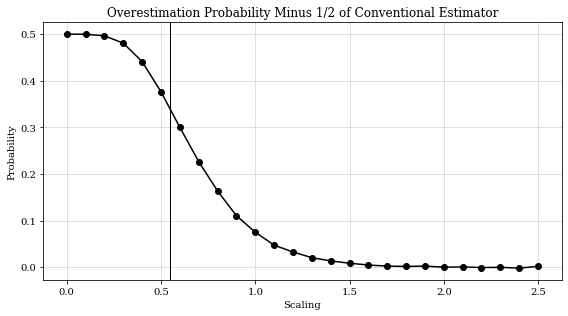

In [8]:
# Overestimation probability
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
overestimate_prob_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    overestimate_prob_arr[idx] = (max_est_arr >= best_mu_arr).mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, overestimate_prob_arr - 0.5, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Probability')
ax.set_title('Overestimation Probability Minus 1/2 of Conventional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, overestimate_prob_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

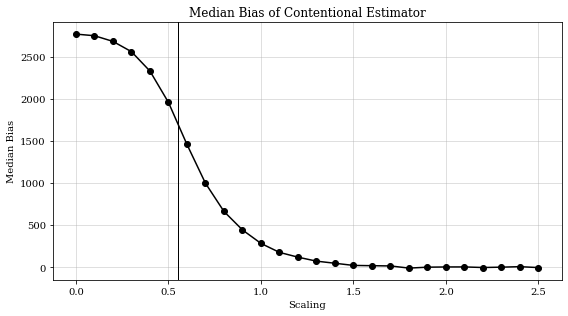

In [9]:
# median bias
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
median_bias_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    median_bias_arr[idx] = np.median(max_est_arr - best_mu_arr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, median_bias_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Median Bias')
ax.set_title('Median Bias of Contentional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, median_bias_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

# Model

## Conditional Inference

In [21]:
def conditional_inference(
    mean_arr: np.ndarray, 
    std_arr: np.ndarray, 
    max_item_idx: int = None, 
    quantile: float = 0.5
) -> float:
    """ 
    Compute the conditional inference method from (Andrews et al. 2024, QJE)
    """
    # if max_item_idx is not provided, find the index of the max item
    if max_item_idx is None:
        max_item_idx = mean_arr.argmax()

    # get the mean and std of the max item
    max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]

    # get the second max mean
    second_max_mean = np.delete(mean_arr, max_item_idx).max()

    def local_truncated_normal_cdf(x, mu) -> float:
        trunc_lb = (second_max_mean - mu) / max_item_std

        return truncnorm.cdf(x, trunc_lb, np.inf, loc=mu, scale=max_item_std)
    
    return fsolve(
        func=lambda mu: local_truncated_normal_cdf(max_item_mean, mu) - 1 + quantile, x0=max_item_mean
    )[0]

In [22]:
mean_arr = mu_arr
std_arr = se_arr

# calculate the related statistics
max_item_idx = mean_arr.argmax()
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the quantile
median_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)

print('Median Estimate:', median_est)

Median Estimate: -1545079.1196766966


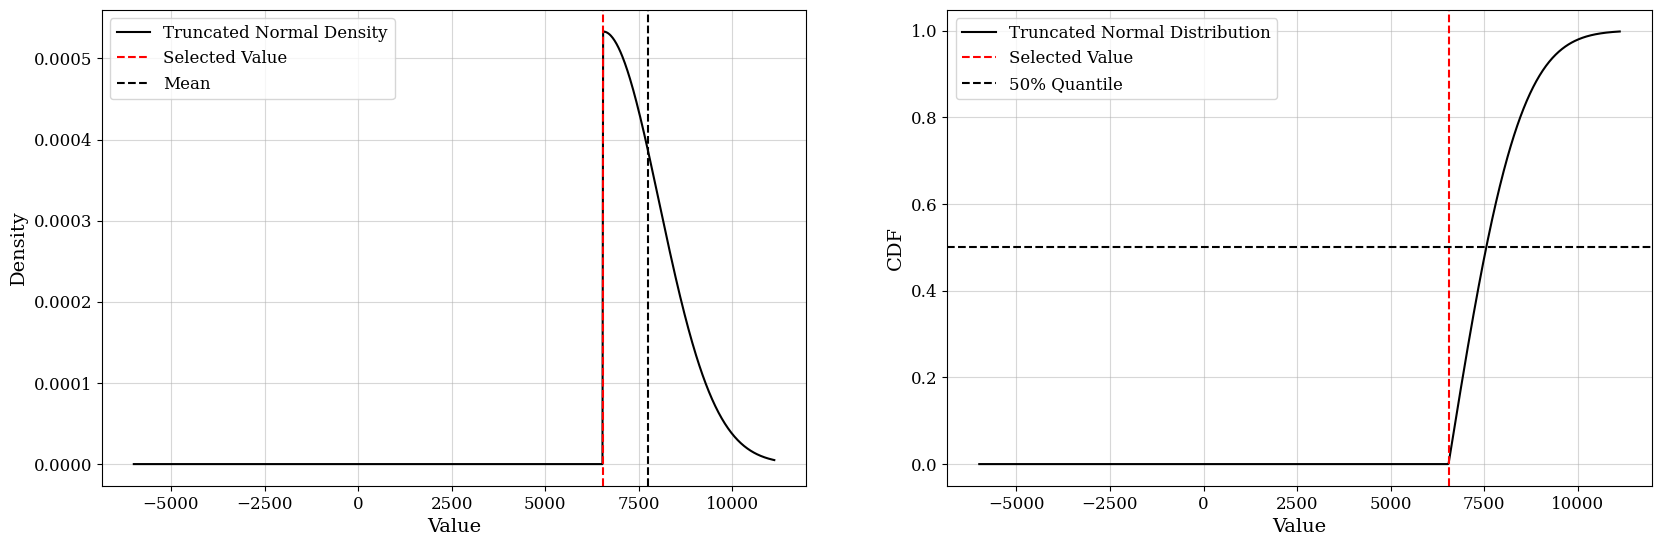

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(mean_arr.min() - 2 * std_arr.max(), mean_arr.max() + 2 * std_arr.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].axvline(truncnorm.mean(a=(second_max_mean - median_est) / max_item_std, b=np.inf, loc=median_est, scale=max_item_std), color='black', linestyle='--', label='Mean')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [13]:
n_repeats = 5000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)
    ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)
    ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
    }

100%|██████████| 5000/5000 [00:16<00:00, 308.48it/s]


In [14]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
err_std = result_df['error'].std()
ci_width = result_df['ci_width'].median()

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Error Std: {err_std:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Coverage Probability: 95.14%
Overestimation Probability: 50.54%
Average Error: -7996.68
Median Error: 26.06
Error Std: 91081.79
Median CI Width: 12485.07


## Unconditional Inference

In [13]:
def unconditional_inference(
    mean_arr: np.ndarray, 
    std_arr: np.ndarray, 
    max_item_idx: int = None, 
    alpha=0.05, n_simulations=10000
):
    """
    Compute the projected simultaneous confidence interval from (Andrews et al. 2024, QJE)
    
    Params:
        mean_arr (np.array): Array of mean estimates for each alternative.
        std_arr (np.array): Array of standard deviations for each alternative.
        max_item_idx (int): Index of the maximum value in the mean_arr.
        alpha (float): Confidence level (1 - alpha). Default is 0.05 for 95% confidence.
        n_simulations (int): Number of Monte Carlo simulations. Default is 100,000.
    
    Returns:
        CI_lower (float): Lower bound of the confidence interval.
        CI_upper (float): Upper bound of the confidence interval.
        C_alpha (float): Critical value for the confidence interval
    """
    # Step 0: If max_item_idx is not provided, find the index of the maximum value
    if max_item_idx is None:
        max_item_idx = mean_arr.argmax()

    # Step 1: Draw samples for Z
    Z_simulations = np.random.multivariate_normal(
        mean=np.zeros_like(mean_arr),
        cov=np.diag(std_arr ** 2), 
        size=n_simulations, 
    )
    
    # Step 2: Scale Z to match the standardization: Xi_theta / sqrt(Sigma_X_theta)
    Z_scaled = Z_simulations / std_arr  # Broadcasting over variances
    
    # Step 3: Compute the maximum of the absolute values for each simulation
    max_abs_Z = np.max(np.abs(Z_scaled), axis=1)  # shape = (n_simulations,)
    
    # Step 4: Determine the (1 - alpha) quantile of the maximum values
    c_alpha = np.quantile(max_abs_Z, 1 - alpha)
    
    # Step 5: Construct the confidence interval
    CI_lower = mean_arr[max_item_idx] - c_alpha * std_arr[max_item_idx]
    CI_upper = mean_arr[max_item_idx] + c_alpha * std_arr[max_item_idx]
    
    return CI_lower, CI_upper, c_alpha

In [102]:
n_repeats = 1000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    ci_lb, ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
    }

100%|██████████| 1000/1000 [00:05<00:00, 190.16it/s]


In [103]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
ci_width = result_df['ci_width'].median()

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Median CI Width: {ci_width:.2f}')

Coverage Probability: 97.50%
Median CI Width: 8655.86


## Hybrid

In [26]:
def hybrid_inference(
    mean_arr: np.ndarray, 
    std_arr: np.ndarray, 
    max_item_idx: int = None, 
    alpha: float = 0.5, 
) -> float:
    """ 
    Compute the hybrid inference method from (Andrews et al. 2024, QJE)
    """
    # calculate beta
    beta = alpha / 10

    # if max_item_idx is not provided, find the index of the max item
    if max_item_idx is None:
        max_item_idx = mean_arr.argmax()

    # get the mean and std of the max item
    max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]

    # calculate c_beta from projection method
    _, _, c_beta = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=beta)

    # get the second max mean
    second_max_mean = np.delete(mean_arr, max_item_idx).max()

    def local_truncated_normal_cdf(x, mu) -> float:
        trunc_lb = max(second_max_mean, max_item_mean - c_beta * max_item_std)
        trunc_ub = max_item_mean + c_beta * max_item_std

        return truncnorm.cdf(
            x, 
            (trunc_lb - mu) / max_item_std, 
            (trunc_ub - mu) / max_item_std, 
            loc=mu, scale=max_item_std
        )
    
    return fsolve(
        func=lambda mu: local_truncated_normal_cdf(max_item_mean, mu) - 1 + alpha, x0=max_item_mean
    )[0]

In [27]:
mean_arr = mu_arr
std_arr = se_arr

# calculate beta
alpha = 0.5
beta = alpha / 10

# if max_item_idx is not provided, find the index of the max item
max_item_idx = mean_arr.argmax()

# get the mean and std of the max item
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]

# calculate c_beta from projection method
_, _, c_beta = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=beta)

# get the second max mean
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the lb and ub of the truncated normal distribution
trunc_lb = max(second_max_mean, max_item_mean - c_beta * max_item_std)
trunc_ub = max_item_mean + c_beta * max_item_std

# calculate the quantile
median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

print('Truncated normal distribution: ')
print(f'Mean: {median_est:.2f}, SD: {max_item_std:.2f}')
print(f'Lower bound: {trunc_lb:.2f}, Upper bound: {trunc_ub:.2f}')

Truncated normal distribution: 
Mean: 6547.00, SD: 1496.17
Lower bound: 2264.75, Upper bound: 10829.25


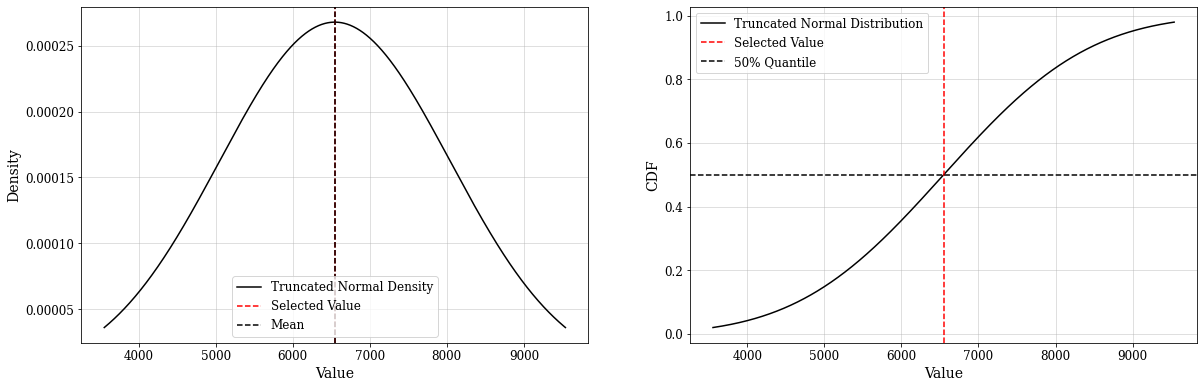

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(median_est - 2 * max_item_std, median_est + 2 * max_item_std, 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].axvline(truncnorm.mean(a=(second_max_mean - median_est) / max_item_std, b=np.inf, loc=median_est, scale=max_item_std), color='black', linestyle='--', label='Mean')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [29]:
n_repeats = 1000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=0.5)
    ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))
    ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))


    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
    }

100%|██████████| 1000/1000 [00:20<00:00, 47.92it/s]


In [30]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
ci_width = result_df['ci_width'].median()

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Coverage Probability: 96.00%
Overestimation Probability: 48.60%
Average Error: -16505.95
Median Error: -83.51
Median CI Width: 14924.15


## Comparison

In [35]:
n_repeats = 100
alpha = 0.05
scaling_arr = np.arange(0, 2.6, 0.1)
result_records = [None] * (scaling_arr.size * n_repeats)

for idx, scaling in tqdm(enumerate(scaling_arr)):
    for j in range(n_repeats):
        mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
        std_arr = np.sqrt(np.diag(cov_arr))

        max_item_idx = mean_arr.argmax()
        max_item_val_true = scaling * mu_arr[max_item_idx]

        # Conventional
        conv_ci_lb = mean_arr[max_item_idx] - 1.96 * std_arr[max_item_idx]
        conv_ci_ub = mean_arr[max_item_idx] + 1.96 * std_arr[max_item_idx]

        # Conditional Inference
        cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)
        cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)

        # Unconditional Inference
        uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

        # Hybrid Inference
        hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))
        hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))

        result_records[idx * n_repeats + j] = {
            'scaling': scaling, 
            'conv_ci_width': conv_ci_ub - conv_ci_lb,
            'cond_ci_width': cond_ci_ub - cond_ci_lb, 
            'uncond_ci_width': uncond_ci_ub - uncond_ci_lb,
            'hybrid_ci_width': hybrid_ci_ub - hybrid_ci_lb,
        }

26it [00:48,  1.86s/it]


In [36]:
result_df = pd.DataFrame.from_records(result_records)
median_ci_width_df = result_df.groupby('scaling').median()

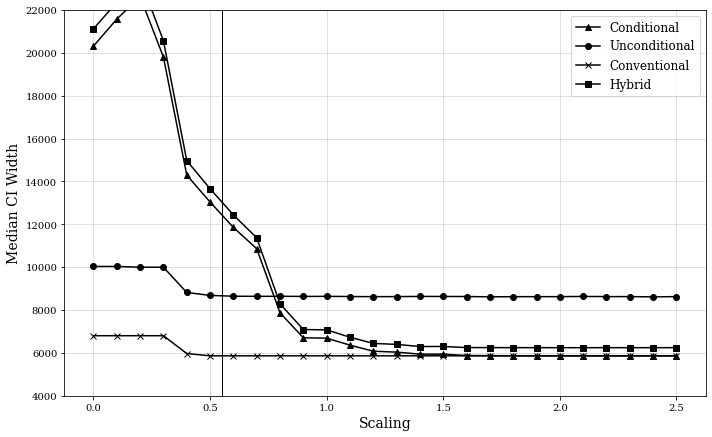

In [37]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(median_ci_width_df.index, median_ci_width_df['cond_ci_width'], marker='^', color='black', label='Conditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['uncond_ci_width'], marker='o', color='black', label='Unconditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['conv_ci_width'], marker='x', color='black', label='Conventional')
ax.plot(median_ci_width_df.index, median_ci_width_df['hybrid_ci_width'], marker='s', color='black', label='Hybrid')

ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)

ax.set_xlabel('Scaling', fontsize=axis_label_size)
ax.set_ylabel('Median CI Width', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

ax.set_ylim(4000, 22000)

plt.tight_layout()
plt.show()

In [34]:
# results summary
alpha = 0.05
mean_arr = mu_arr 
std_arr = se_arr

max_item_idx = mean_arr.argmax()

# conventional
conv_est = mean_arr[max_item_idx]
conv_ci_lb = mean_arr[max_item_idx] - norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]
conv_ci_ub = mean_arr[max_item_idx] + norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]

# conditional inference
cond_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)
cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)
cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)

# unconditional inference
uncond_est = conv_est 
uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

# hybrid inference
hybrid_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=0.5)
hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))
hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))

corrected_inference_df = pd.DataFrame({
    'Conventional': {'Point Estimate': f'${conv_est}', 'CI': f'(${conv_ci_lb:.0f}, ${conv_ci_ub:.0f})'},
    'Conditional': {'Point Estimate': f'${cond_est:.0f}', 'CI': f'(${cond_ci_lb:.0f}, ${cond_ci_ub:.0f})'},
    'Unconditional': {'Point Estimate': f'${uncond_est}', 'CI': f'(${uncond_ci_lb:.0f}, ${uncond_ci_ub:.0f})'},
    'Hybrid': {'Point Estimate': f'${hybrid_est:.0f}', 'CI': f'(${hybrid_ci_lb:.0f}, ${hybrid_ci_ub:.0f})'},
}).T
corrected_inference_df

,Point Estimate,CI
Conventional,$6547,"($3615, $9479)"
Conditional,$6544,"($3494, $9479)"
Unconditional,$6547,"($2223, $10871)"
Hybrid,$6547,"($3422, $9761)"


# Single Segment Binary Targeting

In [61]:
sample_size = 100
noise_std = 1
te_true_arr = np.array([1, 1.1])
treatment_arr = np.random.choice([0, 1], size=sample_size, p=[0.5, 0.5])
outcome_arr = te_true_arr[treatment_arr] + np.random.normal(0, noise_std, sample_size)

In [62]:
te_est_arr = np.array([outcome_arr[treatment_arr == i].mean() for i in range(2)])
est_se_arr = np.array([outcome_arr[treatment_arr == i].std() / np.sqrt(np.sum(treatment_arr == i)) for i in range(2)])

In [63]:
mean_arr = te_est_arr
std_arr = est_se_arr

# calculate the related statistics
max_item_idx = mean_arr.argmax()
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the quantile
median_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)

print('Median Estimate:', median_est)

Median Estimate: 1.2477135919996094


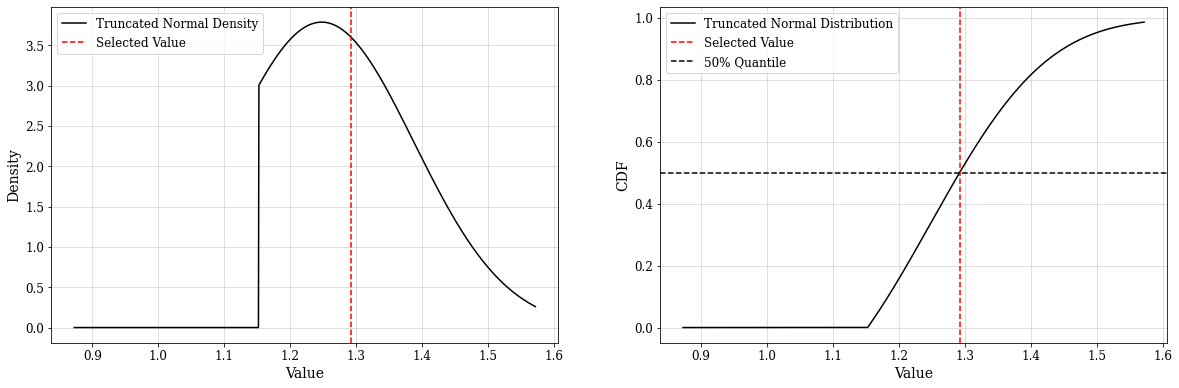

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(mean_arr.min() - 2 * std_arr.max(), mean_arr.max() + 2 * std_arr.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()